# Shoe Brand Classification
**Student:** [Ashwin-Sundar] (ID: [13139477]), [Maria Dharshini] (ID: [13126390])  
**Course:** COMP S492F/COMP3920SEF  
**Date:** April 2026

In [ ]:
# ============================================
# SETUP: GITHUB + GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import pathlib

# --- Configuration ---
repo_url = 'https://github.com/letAshCook/shoe-brand-classification-ml.git'
repo_name = 'shoe-brand-classification-ml'
repo_path = f'/content/{repo_name}'
drive_data_path = '/content/drive/MyDrive/ML_miniProject_data'  # Update if your folder name differs

# --- Reset environment ---
# Always start in /content to avoid "getcwd" errors
os.chdir('/content')

# Remove any existing repo (use absolute path)
!rm -rf {repo_path}

# Clone the repository (Git will create the directory)
!git clone {repo_url} {repo_path}

# Verify clone succeeded
if not os.path.isdir(repo_path):
    raise RuntimeError(f"Git clone failed. Directory {repo_path} not found.")

# Navigate into the repo
os.chdir(repo_path)

# Create symlink to dataset on Drive (only if target exists)
if os.path.exists(drive_data_path):
    !ln -sf {drive_data_path} data
    print(f"✅ Symlinked '{drive_data_path}' -> './data'")
else:
    print(f"⚠️ Warning: Drive path '{drive_data_path}' not found. Symlink not created.")

# Final checks
print("=" * 50)
print("✅ Setup complete!")
print("=" * 50)
print(f"Current directory: {os.getcwd()}")
!ls -l

Mounted at /content/drive
Cloning into '/content/shoe-brand-classification-ml'...
remote: Enumerating objects: 713, done.
remote: Counting objects: 100% (713/713), done.
remote: Compressing objects: 100% (709/709), done.
remote: Total 713 (delta 0), reused 713 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (713/713), 13.08 MiB | 11.67 MiB/s, done.
✅ Symlinked '/content/drive/MyDrive/ML_miniProject_data' -> './data'
✅ Setup complete!
Current directory: /content/shoe-brand-classification-ml
total 0
lrwxrwxrwx 1 root root 42 Apr 25 08:25 data -> /content/drive/MyDrive/ML_miniProject_data


In [ ]:
# ============================================
# IMPORTS
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import pathlib

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.19.0
GPU: True


In [ ]:
# ============================================
# LOAD DATASET
# ============================================

# Dataset is symlinked to ./data
TRAIN_DIR = pathlib.Path('/content/shoe-brand-classification-ml/data/train')
VAL_DIR = pathlib.Path('/content/shoe-brand-classification-ml/data/validate')

print(f"Train exists: {TRAIN_DIR.exists()}")
print(f"Val exists: {VAL_DIR.exists()}")

# Data generators
IMAGE_SIZE = (240, 240)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f"Classes: {CLASS_NAMES}")

Train exists: True
Val exists: True
Found 603 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Classes: ['adidas', 'converse', 'nike']


BUILDING IMPROVED MODEL (EfficientNetB0 + Correct Preprocessing)
Found 603 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Training samples: 603
Validation samples: 90
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,790 (16.83 MB)

 Trainable params: 361,219 (1.38 MB)

...


Epoch 2: finished saving model to best_model_v2.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 603ms/step - accuracy: 0.6551 - loss: 1.3371 - val_accuracy: 0.7222 - val_loss: 1.1832 - learning_rate: 0.0010
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.7811 - loss: 1.1317
Epoch 3: val_accuracy did not improve from 0.72222
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 528ms/step - accuracy: 0.7828 - loss: 1.1103 - val_accuracy: 0.7222 - val_loss: 1.1708 - learning_rate: 0.0010
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.7858 - loss: 1.0185
Epoch 4: val_accuracy improved from 0.72222 to 0.78889, saving model to best_model_v2.h5



Epoch 4: finished saving model to best_model_v2.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 543ms/step - accuracy: 0.8060 - loss: 0.9999 - val_accuracy: 0.7889 - val_loss: 1.0367 - learning_rate: 0.0010
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.8379 - loss: 0.9439
Epoch 5: val_accuracy improved from 0.78889 to 0.83333, saving model to best_model_v2.h5



Epoch 5: finished saving model to best_model_v2.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 606ms/step - accuracy: 0.8308 - loss: 0.9660 - val_accuracy: 0.8333 - val_loss: 0.9998 - learning_rate: 0.0010
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.8599 - loss: 0.8851
Epoch 6: val_accuracy improved from 0.83333 to 0.87778, saving model to best_model_v2.h5



Epoch 6: finished saving model to best_model_v2.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 596ms/step - accuracy: 0.8640 - loss: 0.8673 - val_accuracy: 0.8778 - val_loss: 0.9254 - learning_rate: 0.0010
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.8693 - loss: 0.8256
Epoch 7: val_accuracy did not improve from 0.87778
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 564ms/step - accuracy: 0.8740 - loss: 0.8205 - val_accuracy: 0.8333 - val_loss: 0.9506 - learning_rate: 0.0010
Epoch 8/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8862 - loss: 0.7582
Epoch 8: val_accuracy did not improve from 0.87778
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 475ms/step - accuracy: 0.8872 - loss: 0.7633 - val_accuracy: 0.8444 - val_loss: 0.8933 - learning_rate: 0.0010
Epoch 9/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.8689 - loss: 0.7558
Epoch 9: val_accuracy did not improve from 0.87778
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 564ms/step - accuracy: 0.8839 - loss: 0.7345 - val_accuracy: 0.8444 - val_loss: 0


Epoch 10: finished saving model to best_model_v2.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 602ms/step - accuracy: 0.8988 - loss: 0.6968 - val_accuracy: 0.9000 - val_loss: 0.8752 - learning_rate: 0.0010
Epoch 11/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9369 - loss: 0.6349
Epoch 11: val_accuracy did not improve from 0.90000
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 579ms/step - accuracy: 0.9320 - loss: 0.6374 - val_accuracy: 0.8556 - val_loss: 0.8868 - learning_rate: 0.0010
Epoch 12/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9214 - loss: 0.6292
Epoch 12: val_accuracy did not improve from 0.90000

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 481ms/step - accuracy: 0.9353 - loss: 0.6128 - val_accuracy: 0.8333 - val_loss: 0.8866 - learning_rate: 0.0010
Epoch 13/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9216 - loss: 0.6083
Epoch 13: val_accuracy did not improve from 0.90000
19/19 ━━━━━━━━━━━━━━━━━━━━ 

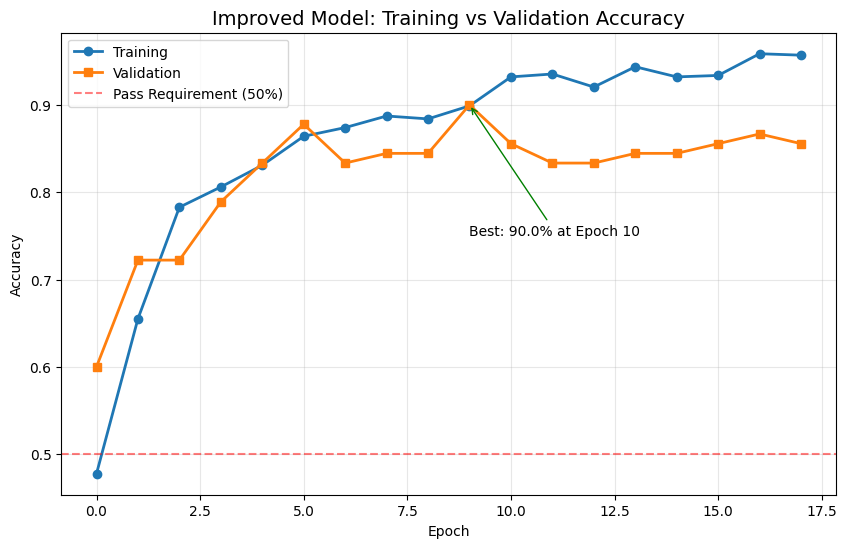


✅ Best Validation Accuracy: 0.9000 (90.00%)


In [ ]:
# ============================================
# EFFICIENTNETB0 WITH CORRECT PREPROCESSING
# ============================================

print("=" * 60)
print("BUILDING IMPROVED MODEL (EfficientNetB0 + Correct Preprocessing)")
print("=" * 60)

import tensorflow as tf
from tensorflow.keras import layers, regularizers

# ------------------------------------------------------------
# 1. PREPROCESSING FOR EFFICIENTNET
# ------------------------------------------------------------
# EfficientNet requires its own preprocess_input function
from tensorflow.keras.applications.efficientnet import preprocess_input

# Moderate augmentation (safe but effective)
train_datagen_v2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✅ KEY FIX
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_datagen_v2 = ImageDataGenerator(
    preprocessing_function=preprocess_input   # ✅ Use same preprocessing
)

# Reload generators using existing TRAIN_DIR/VAL_DIR (must be defined)
train_gen_v2 = train_datagen_v2.flow_from_directory(
    TRAIN_DIR,
    target_size=(240, 240),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_gen_v2 = val_datagen_v2.flow_from_directory(
    VAL_DIR,
    target_size=(240, 240),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f"Training samples: {train_gen_v2.samples}")
print(f"Validation samples: {val_gen_v2.samples}")

# ------------------------------------------------------------
# 2. BUILD EFFICIENTNETB0 MODEL
# ------------------------------------------------------------
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(240, 240, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False

model_v2 = tf.keras.Sequential([
    base_model,
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

# ------------------------------------------------------------
# 3. TRAIN WITH CALLBACKS
# ------------------------------------------------------------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model_v2.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("\n" + "=" * 60)
print("TRAINING IMPROVED MODEL (up to 25 epochs)")
print("=" * 60)

history_v2 = model_v2.fit(
    train_gen_v2,
    epochs=25,
    validation_data=val_gen_v2,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# 4. PLOT RESULTS
# ------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_v2.history['accuracy'], 'o-', label='Training', linewidth=2)
plt.plot(history_v2.history['val_accuracy'], 's-', label='Validation', linewidth=2)
plt.title('Improved Model: Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

best_acc = max(history_v2.history['val_accuracy'])
best_epoch = history_v2.history['val_accuracy'].index(best_acc) + 1
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Pass Requirement (50%)')
plt.annotate(f'Best: {best_acc:.1%} at Epoch {best_epoch}',
            xy=(best_epoch-1, best_acc),
            xytext=(best_epoch-1, best_acc-0.15),
            arrowprops=dict(arrowstyle='->', color='green'))

plt.legend()
plt.show()

print(f"\n✅ Best Validation Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

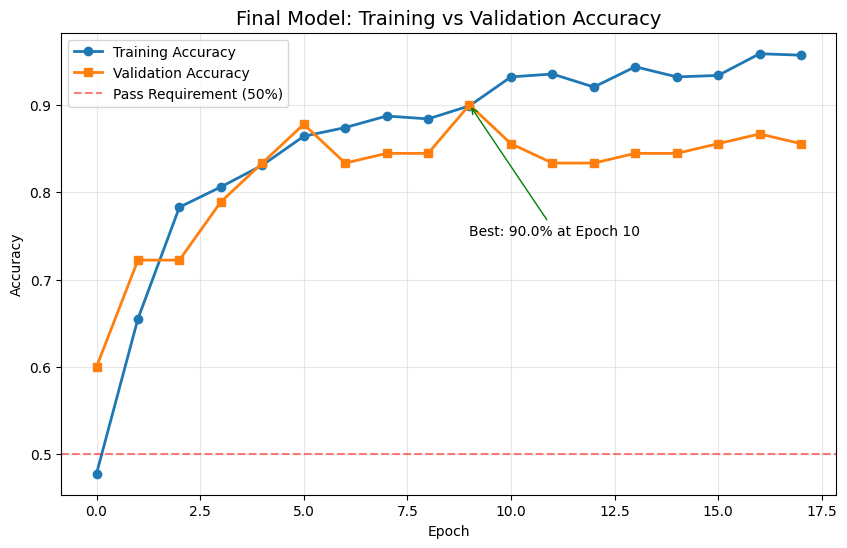

Best Validation Accuracy: 0.9000 (90.00%)


In [ ]:
# ============================================
# FINAL ACCURACY PLOT (FOR SUBMISSION)
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_v2.history['accuracy'], 'o-', label='Training Accuracy', linewidth=2, color='#1f77b4')
plt.plot(history_v2.history['val_accuracy'], 's-', label='Validation Accuracy', linewidth=2, color='#ff7f0e')
plt.title('Final Model: Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Pass Requirement (50%)')
plt.legend()
plt.grid(True, alpha=0.3)

best_acc = max(history_v2.history['val_accuracy'])
best_epoch = history_v2.history['val_accuracy'].index(best_acc) + 1
plt.annotate(f'Best: {best_acc:.1%} at Epoch {best_epoch}',
             xy=(best_epoch-1, best_acc),
             xytext=(best_epoch-1, best_acc-0.15),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10)

plt.show()

print(f"Best Validation Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

In [ ]:
# ============================================
# FIX: SAVE IN .keras FORMAT AND RELOAD PROPERLY
# ============================================

print("=" * 50)
print("SAVING AND RELOADING WITH .keras FORMAT")
print("=" * 50)

# 1. Save in the recommended .keras format
model_v2.save('shoe_classifier_model.keras')
print("✅ Model saved as 'shoe_classifier_model.keras'")

# 2. Check file size
import os
size_mb = os.path.getsize('shoe_classifier_model.keras') / (1024*1024)
print(f"📦 Model size: {size_mb:.2f} MB")

# 3. Load the model
from tensorflow.keras.models import load_model
loaded_model = load_model('shoe_classifier_model.keras')

# 4. Re-compile (important for metrics to be built correctly)
loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Model loaded and re-compiled")

# 5. Evaluate on validation set
loss, acc = loaded_model.evaluate(val_gen_v2, verbose=1)
print(f"\n{'='*40}")
print(f"Reloaded Validation Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"{'='*40}")

if acc >= 0.5:
    print("✅ PASS: 50% requirement met!")

SAVING AND RELOADING WITH .keras FORMAT
✅ Model saved as 'shoe_classifier_model.keras'
📦 Model size: 20.40 MB


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Model loaded and re-compiled
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9000 - loss: 0.8752

Reloaded Validation Accuracy: 0.9000 (90.00%)
✅ PASS: 50% requirement met!


In [ ]:
from google.colab import files
files.download('shoe_classifier_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# SAVE THE IN-MEMORY MODEL (RESTORED BEST WEIGHTS)
# ============================================

loss_in_mem, acc_in_mem = model_v2.evaluate(val_gen_v2, verbose=0)
print(f"In-memory model accuracy: {acc_in_mem:.4f} ({acc_in_mem*100:.2f}%)")

# Save it as the official final model (overwrites any previous file)
model_v2.save('/content/shoe-brand-classification-ml/shoe_classifier_model.keras')
print("✅ Saved in-memory model as '/content/shoe-brand-classification-ml/shoe_classifier_model.keras'")

# Reload and verify
from tensorflow.keras.models import load_model
reloaded = load_model('/content/shoe-brand-classification-ml/shoe_classifier_model.keras')
reload_loss, reload_acc = reloaded.evaluate(val_gen_v2, verbose=0)
print(f"Reloaded model accuracy: {reload_acc:.4f} ({reload_acc*100:.2f}%)")

In-memory model accuracy: 0.9000 (90.00%)
✅ Saved in-memory model as '/content/shoe-brand-classification-ml/shoe_classifier_model.keras'
Reloaded model accuracy: 0.9000 (90.00%)


In [ ]:
# ============================================
# FINAL MODEL RELOADING TEST (TUTOR VERSION)
# ============================================

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import pathlib

# Preprocessing (same as training)
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(240, 240),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Load model (from .keras file)
model = load_model('/content/shoe-brand-classification-ml/shoe_classifier_model.keras')

# Re-compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Evaluate
loss, acc = model.evaluate(val_gen, verbose=1)
print(f"\nValidation Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Found 90 images belonging to 3 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9000 - loss: 0.8752

Validation Accuracy: 0.9000 (90.00%)
